# Air Quality Analysis and Visualization

## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [4]:
df = pd.read_csv("AirQualityUCI.csv", sep=";", decimal=",", encoding="latin1")
df = df.dropna(axis=1, how="all")
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 3. Dataset Information

In [5]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())
print("\nDataset Information:")
df.info()

Dataset Shape: (9471, 15)

First 5 Rows:


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), str(2)
memory usage: 1.1 MB


## 4. Data Cleaning

In [6]:
df = df.replace(-200, np.nan)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
numeric_columns = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", "T", "RH"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
Date              114
Time              114
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64


## 5. Statistical Summary

In [7]:
print(df.describe())

                             Date       CO(GT)  PT08.S1(CO)     NMHC(GT)  \
count                        9357  7674.000000  8991.000000   914.000000   
mean   2004-09-21 04:30:05.193972     2.152750  1099.833166   218.811816   
min           2004-03-10 00:00:00     0.100000   647.000000     7.000000   
25%           2004-06-16 00:00:00     1.100000   937.000000    67.000000   
50%           2004-09-21 00:00:00     1.800000  1063.000000   150.000000   
75%           2004-12-28 00:00:00     2.900000  1231.000000   297.000000   
max           2005-04-04 00:00:00    11.900000  2040.000000  1189.000000   
std                           NaN     1.453252   217.080037   204.459921   

          C6H6(GT)  PT08.S2(NMHC)      NOx(GT)  PT08.S3(NOx)      NO2(GT)  \
count  8991.000000    8991.000000  7718.000000   8991.000000  7715.000000   
mean     10.083105     939.153376   246.896735    835.493605   113.091251   
min       0.100000     383.000000     2.000000    322.000000     2.000000   
25%    

## 6. Average Pollution Levels

In [8]:
pollution_columns = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
average_pollution = df[pollution_columns].mean().sort_values(ascending=False)
print(average_pollution)

NOx(GT)     246.896735
NO2(GT)     113.091251
C6H6(GT)     10.083105
CO(GT)        2.152750
dtype: float64


## 7. CO Concentration Over Time

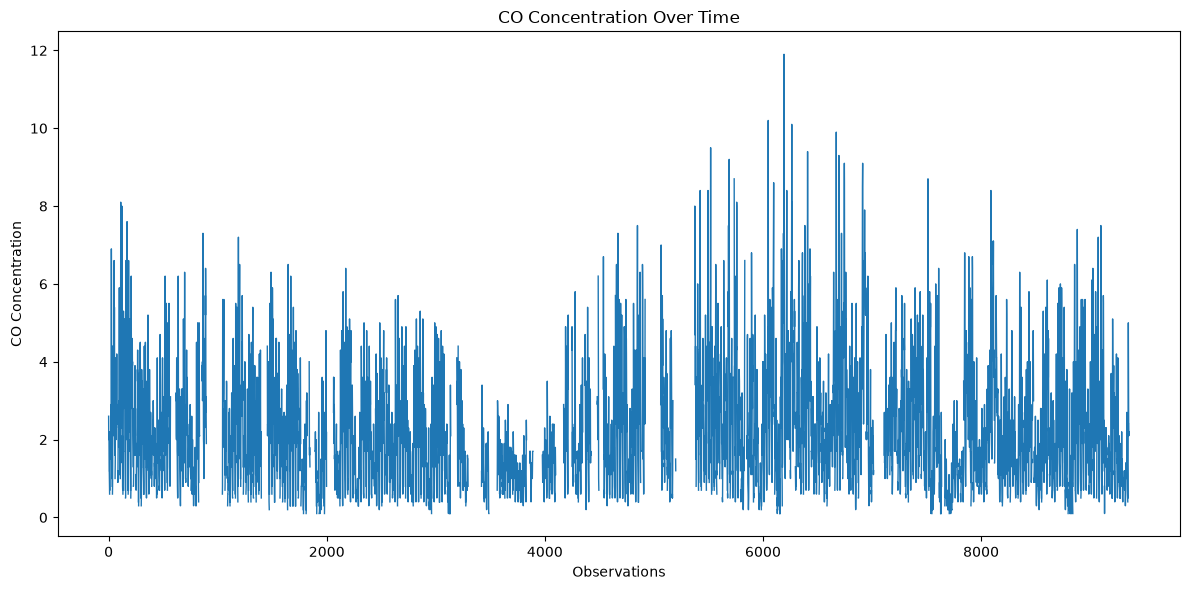

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(df["CO(GT)"], linewidth=1)
plt.title("CO Concentration Over Time")
plt.xlabel("Observations")
plt.ylabel("CO Concentration")
plt.tight_layout()
plt.show()

## 8. NO2 Concentration Over Time

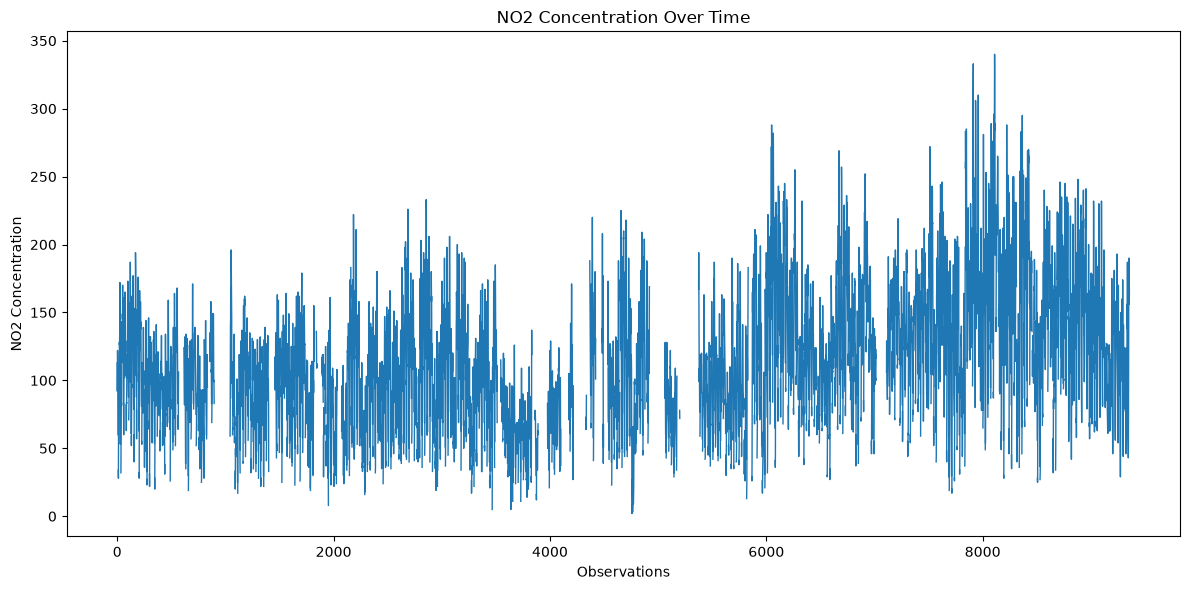

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(df["NO2(GT)"], linewidth=1)
plt.title("NO2 Concentration Over Time")
plt.xlabel("Observations")
plt.ylabel("NO2 Concentration")
plt.tight_layout()
plt.show()

## 9. CO Concentration Distribution

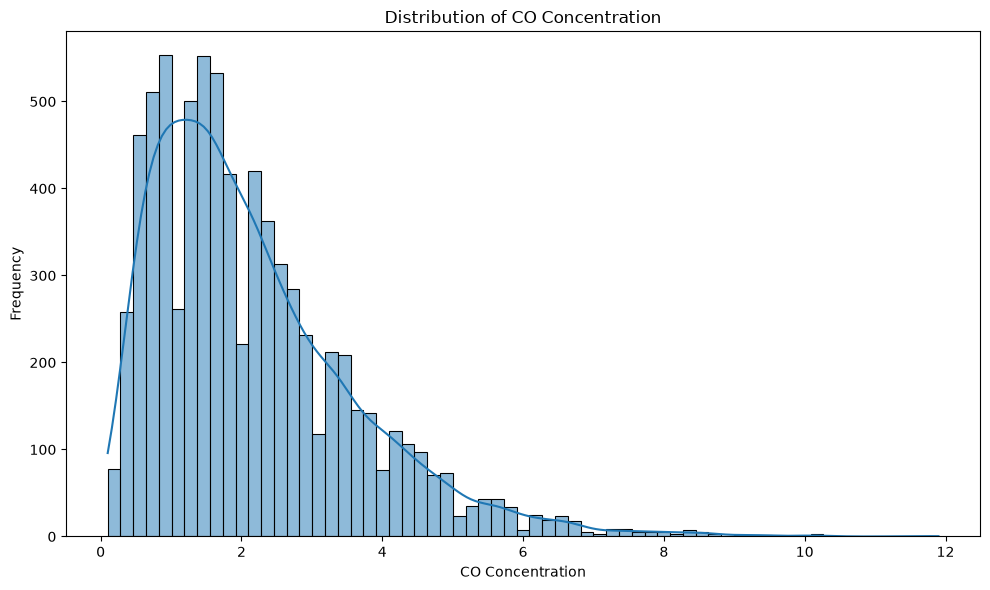

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df["CO(GT)"].dropna(), kde=True)
plt.title("Distribution of CO Concentration")
plt.xlabel("CO Concentration")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 10. Temperature vs NO2

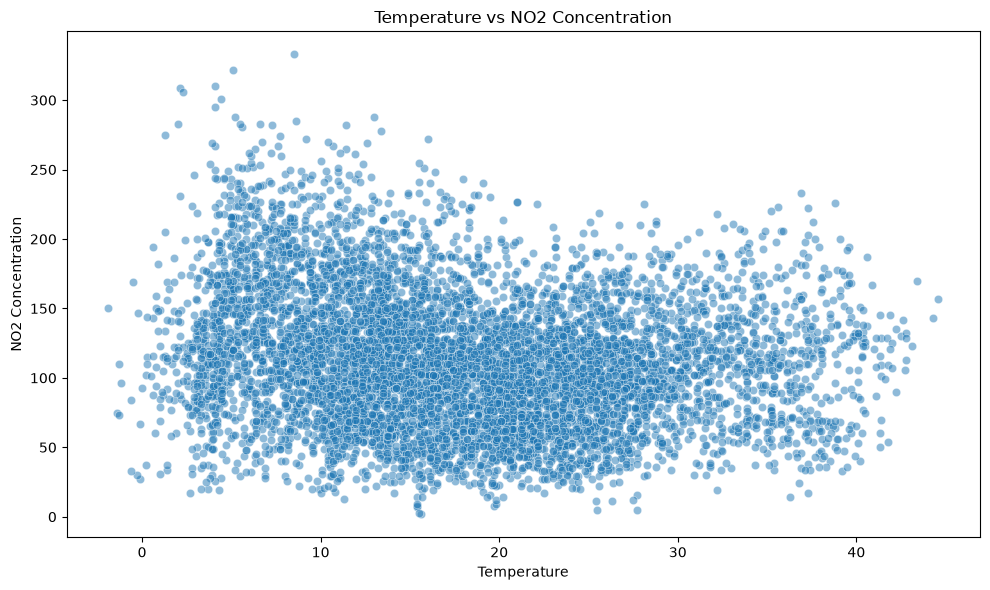

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="T", y="NO2(GT)", alpha=0.5)
plt.title("Temperature vs NO2 Concentration")
plt.xlabel("Temperature")
plt.ylabel("NO2 Concentration")
plt.tight_layout()
plt.show()

## 11. Correlation Heatmap

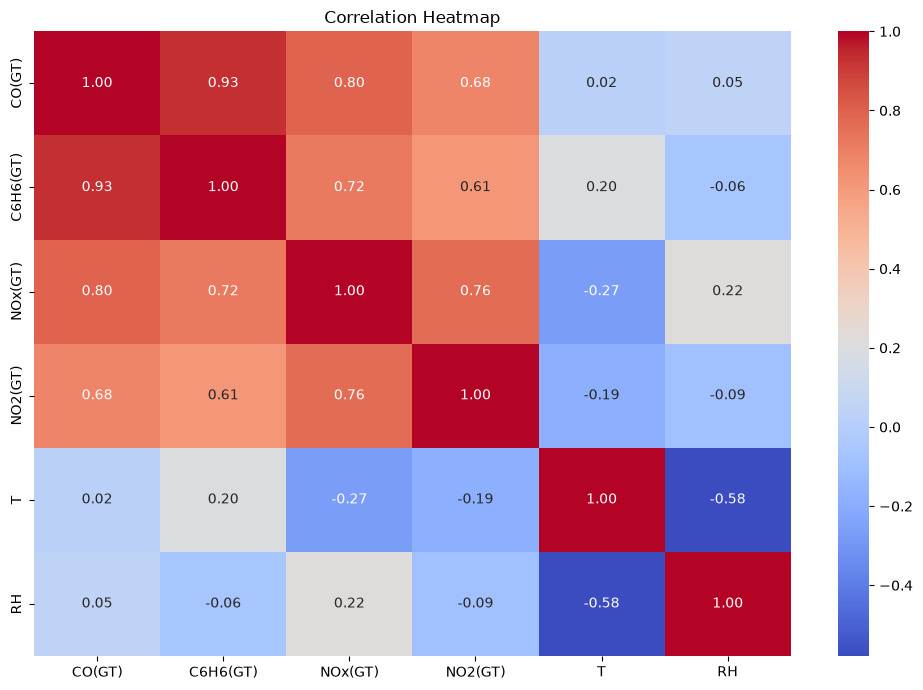

In [13]:
correlation_columns = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", "T", "RH"]
correlation_matrix = df[correlation_columns].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 12. Monthly Pollution Analysis

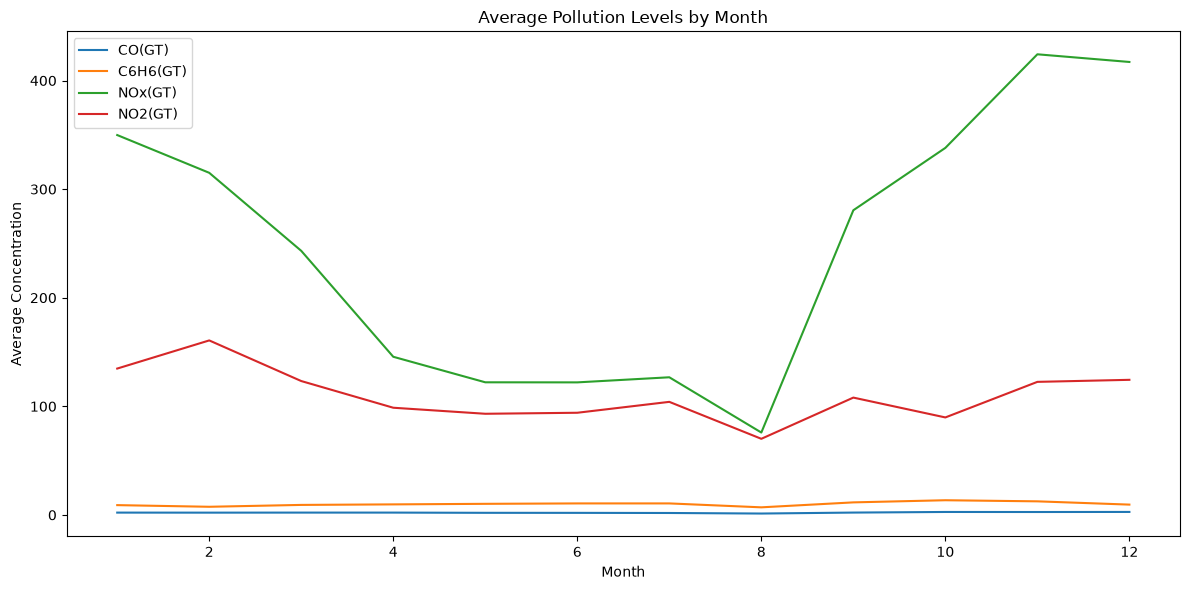

In [14]:
monthly_data = df.groupby(df["Date"].dt.month)[pollution_columns].mean()
monthly_data.plot(figsize=(12, 6))
plt.title("Average Pollution Levels by Month")
plt.xlabel("Month")
plt.ylabel("Average Concentration")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Maximum Pollution Values

In [15]:
print(df[pollution_columns].max())

CO(GT)        11.9
C6H6(GT)      63.7
NOx(GT)     1479.0
NO2(GT)      340.0
dtype: float64


## 14. Minimum Pollution Values

In [16]:
print(df[pollution_columns].min())

CO(GT)      0.1
C6H6(GT)    0.1
NOx(GT)     2.0
NO2(GT)     2.0
dtype: float64


## 15. Correlation Analysis

In [17]:
print(correlation_matrix)

            CO(GT)  C6H6(GT)   NOx(GT)   NO2(GT)         T        RH
CO(GT)    1.000000  0.931078  0.795028  0.683343  0.022109  0.048890
C6H6(GT)  0.931078  1.000000  0.718839  0.614474  0.198956 -0.061681
NOx(GT)   0.795028  0.718839  1.000000  0.763111 -0.269683  0.221032
NO2(GT)   0.683343  0.614474  0.763111  1.000000 -0.186533 -0.091759
T         0.022109  0.198956 -0.269683 -0.186533  1.000000 -0.578621
RH        0.048890 -0.061681  0.221032 -0.091759 -0.578621  1.000000


## 16. Key Findings

In [18]:
print("Key Findings")
print("1. The dataset contains air-quality measurements collected over time.")
print("2. Missing or invalid values represented by -200 were converted to NaN.")
print("3. CO and NO2 trends were visualized over the observations.")
print("4. The CO distribution shows how frequently different concentration values occur.")
print("5. The scatter plot helps examine the relationship between temperature and NO2.")
print("6. The correlation heatmap shows relationships among major pollutants and environmental variables.")
print("7. Monthly averages provide a broader view of pollution variation across the year.")

Key Findings
1. The dataset contains air-quality measurements collected over time.
2. Missing or invalid values represented by -200 were converted to NaN.
3. CO and NO2 trends were visualized over the observations.
4. The CO distribution shows how frequently different concentration values occur.
5. The scatter plot helps examine the relationship between temperature and NO2.
6. The correlation heatmap shows relationships among major pollutants and environmental variables.
7. Monthly averages provide a broader view of pollution variation across the year.


## 17. Conclusion

In [19]:
print("Air Quality Analysis Completed Successfully.")
print("The analysis demonstrates data loading, cleaning, statistical analysis, visualization and correlation analysis using Python.")

Air Quality Analysis Completed Successfully.
The analysis demonstrates data loading, cleaning, statistical analysis, visualization and correlation analysis using Python.
